In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the training dataset
df = pd.read_csv(r"D:\House Price Prediction\train.csv")

# Display the first five rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Display the dataset dimensions
print("Shape:", df.shape)

# Display column names
print("\nColumns:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
print(df.dtypes)

# Display missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Display duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Display summary statistics
df.describe(include="all")

Shape: (1460, 81)

Columns:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'Screen

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,...,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,...,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,...,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,...,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,...,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,...,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000
25%,365.750000,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000
50%,730.500000,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000
75%,1095.250000,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000


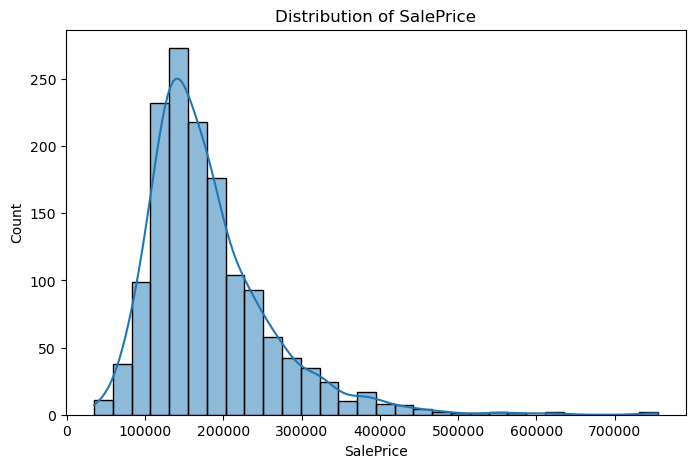

In [5]:
#EDA
# Plot the distribution of the target variable
plt.figure(figsize=(8, 5))
sns.histplot(df["SalePrice"], bins=30, kde=True)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

In [6]:
# Display the top 10 features most correlated with SalePrice
correlation = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
correlation.head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

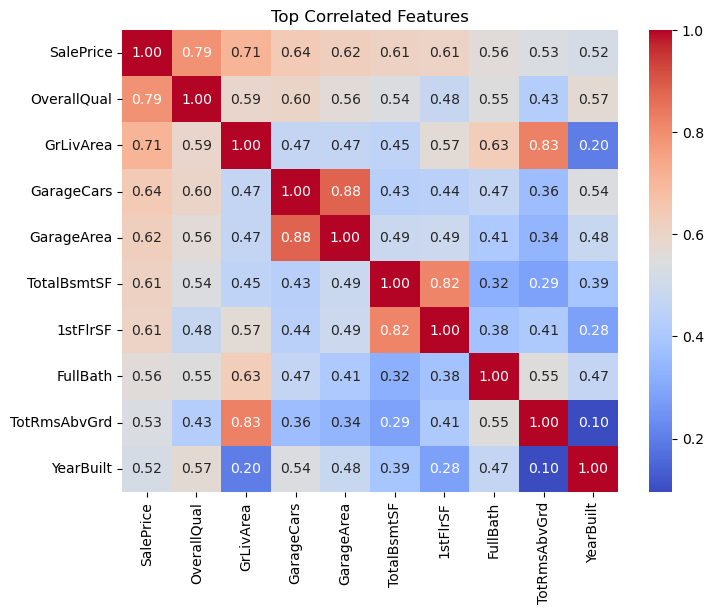

In [7]:
# Plot the heatmap of the top correlated features
top_features = correlation.head(10).index

plt.figure(figsize=(8, 6))
sns.heatmap(df[top_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Top Correlated Features")
plt.show()

In [8]:
# Display columns with missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

missing_values

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [9]:
# Drop columns with excessive missing values
df.drop(["PoolQC", "MiscFeature", "Alley", "Fence"], axis=1, inplace=True)

In [10]:
# Fill numerical missing values with the median
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())
df["MasVnrArea"] = df["MasVnrArea"].fillna(df["MasVnrArea"].median())
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["GarageYrBlt"].median())

In [11]:
# Fill garage-related missing values
garage_cols = ["GarageType", "GarageFinish", "GarageQual", "GarageCond"]

for col in garage_cols:
    df[col] = df[col].fillna("None")


# Fill basement-related missing values
bsmt_cols = ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]

for col in bsmt_cols:
    df[col] = df[col].fillna("None")



# Fill the remaining categorical missing values
df["MasVnrType"] = df["MasVnrType"].fillna("None")
df["FireplaceQu"] = df["FireplaceQu"].fillna("None")
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

In [12]:
# Check whether any missing values remain
df.isnull().sum().sort_values(ascending=False).head(10)

Id              0
HalfBath        0
FireplaceQu     0
Fireplaces      0
Functional      0
TotRmsAbvGrd    0
KitchenQual     0
KitchenAbvGr    0
BedroomAbvGr    0
FullBath        0
dtype: int64

In [13]:
# Encode all categorical features
df = pd.get_dummies(df, drop_first=True, dtype=int)

# Check if any categorical columns remain
df.select_dtypes(include="object").columns

Index([], dtype='object')

In [14]:
# Separate input features and target variable
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [15]:
# Import the train-test split function
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
# Import the Linear Regression model
from sklearn.linear_model import LinearRegression

# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Predict house prices for the test data
y_pred_linear = linear_model.predict(X_test)

In [17]:
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define a function to evaluate regression models
def evaluate_model(model_name, y_test, y_pred):

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name} Performance")
    print(f"MAE      : {mae:.2f}")
    print(f"MSE      : {mse:.2f}")
    print(f"RMSE     : {rmse:.2f}")
    print(f"R² Score : {r2:.4f}")

In [18]:
# Evaluate the Linear Regression model
evaluate_model("Linear Regression", y_test, y_pred_linear)


Linear Regression Performance
MAE      : 20667.19
MSE      : 2759384347.01
RMSE     : 52529.84
R² Score : 0.6403


In [19]:
# Import the Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

# Create the Decision Tree model
decision_tree_model = DecisionTreeRegressor(random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

# Predict house prices for the test data
y_pred_decision_tree = decision_tree_model.predict(X_test)



# Evaluate the Decision Tree model
evaluate_model("Decision Tree", y_test, y_pred_decision_tree)


Decision Tree Performance
MAE      : 27588.30
MSE      : 1853065417.92
RMSE     : 43047.25
R² Score : 0.7584


In [20]:
# Import the Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Predict house prices for the test data
y_pred_random_forest = random_forest_model.predict(X_test)




# Evaluate the Random Forest model
evaluate_model("Random Forest", y_test, y_pred_random_forest)


Random Forest Performance
MAE      : 17777.94
MSE      : 870960587.08
RMSE     : 29512.04
R² Score : 0.8865


In [21]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [22]:
# Import the XGBoost Regressor
from xgboost import XGBRegressor

# Create the XGBoost model
xgboost_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train the model
xgboost_model.fit(X_train, y_train)

# Predict house prices for the test data
y_pred_xgboost = xgboost_model.predict(X_test)


# Evaluate the XGBoost model
evaluate_model("XGBoost", y_test, y_pred_xgboost)


XGBoost Performance
MAE      : 15272.54
MSE      : 576706176.00
RMSE     : 24014.71
R² Score : 0.9248


In [23]:
# Create a comparison table for all models
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        20667.19,
        27588.30,
        17777.94,
        15272.54
    ],
    "MSE": [
        2759384347.01,
        1853065417.92,
        870960587.08,
        576706176.00
    ],
    "RMSE": [
        52529.84,
        43047.25,
        29512.04,
        24014.71
    ],
    "R² Score": [
        0.6403,
        0.7584,
        0.8865,
        0.9248
    ]
})

# Display the comparison table
comparison

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,20667.19,2.759384e+09,52529.84,0.6403
1,Decision Tree,27588.30,1.853065e+09,43047.25,0.7584
2,Random Forest,17777.94,8.709606e+08,29512.04,0.8865
3,XGBoost,15272.54,5.767062e+08,24014.71,0.9248


In [24]:
# Load the test dataset
test_df = pd.read_csv(r"D:\House Price Prediction\test.csv")

In [25]:
# Save the Id column
test_ids = test_df["Id"]

In [26]:
test_df.drop(["PoolQC", "MiscFeature", "Alley", "Fence"], axis=1, inplace=True)

test_df["LotFrontage"] = test_df["LotFrontage"].fillna(test_df["LotFrontage"].median())
test_df["MasVnrArea"] = test_df["MasVnrArea"].fillna(test_df["MasVnrArea"].median())
test_df["GarageYrBlt"] = test_df["GarageYrBlt"].fillna(test_df["GarageYrBlt"].median())

garage_cols = ["GarageType", "GarageFinish", "GarageQual", "GarageCond"]

for col in garage_cols:
    test_df[col] = test_df[col].fillna("None")

bsmt_cols = ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]

for col in bsmt_cols:
    test_df[col] = test_df[col].fillna("None")


test_df["MasVnrType"] = test_df["MasVnrType"].fillna("None")
test_df["FireplaceQu"] = test_df["FireplaceQu"].fillna("None")
test_df["Electrical"] = test_df["Electrical"].fillna(test_df["Electrical"].mode()[0])

In [27]:
test_df = pd.get_dummies(test_df, drop_first=True, dtype=int)

In [28]:
# Match the columns used during training
test_df = test_df.reindex(columns=X_train.columns, fill_value=0)

In [29]:
# Predict SalePrice
predictions = xgboost_model.predict(test_df)
predictions


array([124969.07, 160141.61, 187056.98, ..., 175420.42, 123235.4 ,
       225957.58], shape=(1459,), dtype=float32)

In [30]:
# Create the submission dataframe
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": predictions
})

In [31]:
# Save the submission file
submission.to_csv("submission.csv", index=False)